# Handwritten Digit Recognition

This notebook covers:
- intro & imports
- loading the dataset
- normalizing the data
- one-hot encoding (for demonstration)
- previewing the data (`display_sample(num)`) 
- defining a neural network (MLP)
- setting up loss & optimizer
- training loop
- evaluating & plotting accuracy/loss
- visualizing predictions
- ideas for improving model performance (CNN, augmentation, etc.)

## Intro
**Objective:** Classify 28×28 grayscale digits 0–9.
**Approach:** Small CNN from scratch → compare with LeNet‑5; label smoothing + augmentation (random affine, elastic).
**Data:** 60k train / 10k test, balanced
**Result:** TEST_ACC%; robust to small rotations (+/‑ 15°).
**Stack:** PyTorch/TensorFlow, torchvision/keras, matplotlib.

## Imports

In [1]:
import torch
from torch import nn
from torch.utils.data import DataLoader
from torchvision import datasets, transforms
import matplotlib.pyplot as plt
from pathlib import Path
import numpy as np

In [2]:
print(torch.backends.mps.is_available())

True


In [3]:
# set device
# device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
device = torch.device("mps" if torch.backends.mps.is_available() else "cpu")
device

device(type='mps')

## Load the MNIST dataset

In [4]:
data_dir = Path('./data')

# basic transform: to tensor (scales to [0,1])
base_transform = transforms.ToTensor()

train_dataset = datasets.MNIST(
    root=data_dir,
    train=True,
    download=True,
    transform=base_transform,
)
test_dataset = datasets.MNIST(
    root=data_dir,
    train=False,
    download=True,
    transform=base_transform,
)
len(train_dataset), len(test_dataset)

(60000, 10000)

## Normalize the data
PyTorch's `ToTensor()` already scales to `[0,1]`. If you want to normalize to MNIST's mean/std, do this:

In [5]:
mnist_mean = 0.1307
mnist_std = 0.3081

norm_transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((mnist_mean,), (mnist_std,)),
])

# apply to datasets
train_dataset.transform = norm_transform
test_dataset.transform = norm_transform

## One-hot encode (for demonstration)
PyTorch's `nn.CrossEntropyLoss` expects **integer class indices**, not one-hot vectors. But we'll keep this section to illustrate one-hot encoding.

In [6]:
def to_one_hot(labels: torch.Tensor, num_classes: int = 10):
    return torch.eye(num_classes)[labels]

# demo
demo_labels = torch.tensor([0, 1, 5])
to_one_hot(demo_labels, 10)

tensor([[1., 0., 0., 0., 0., 0., 0., 0., 0., 0.],
        [0., 1., 0., 0., 0., 0., 0., 0., 0., 0.],
        [0., 0., 0., 0., 0., 1., 0., 0., 0., 0.]])

## Preview the data

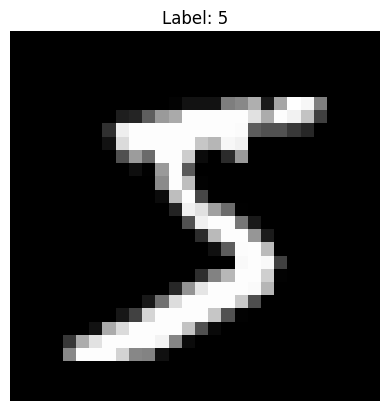

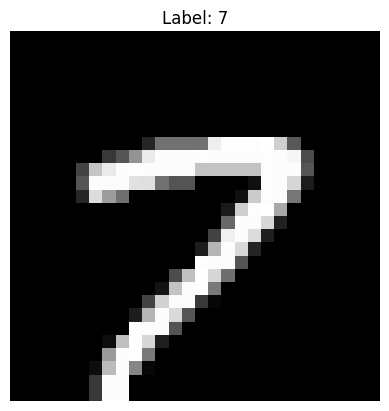

In [7]:
def display_sample(idx: int):
    img, label = train_dataset[idx]
    plt.imshow(img.squeeze(0), cmap='gray')
    plt.title(f'Label: {label}')
    plt.axis('off')
    plt.show()

# try a few
display_sample(0)
display_sample(123)

## MLP
### Define a simple MLP model

In [8]:
class MNISTMLP(nn.Module):
    def __init__(self):
        super().__init__()
        self.flatten = nn.Flatten()
        self.net = nn.Sequential(
            nn.Linear(28*28, 256),
            nn.ReLU(),
            nn.Linear(256, 128),
            nn.ReLU(),
            nn.Linear(128, 10),  # logits
        )

    def forward(self, x):
        x = self.flatten(x)
        return self.net(x)

model = MNISTMLP().to(device)
model

MNISTMLP(
  (flatten): Flatten(start_dim=1, end_dim=-1)
  (net): Sequential(
    (0): Linear(in_features=784, out_features=256, bias=True)
    (1): ReLU()
    (2): Linear(in_features=256, out_features=128, bias=True)
    (3): ReLU()
    (4): Linear(in_features=128, out_features=10, bias=True)
  )
)

### Loss function and optimizer

In [9]:
loss_fn = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)

### DataLoaders and training loop

In [11]:
batch_size = 64

train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

def train_one_epoch(model, dataloader, loss_fn, optimizer, device):
    model.train()
    running_loss = 0.0
    correct = 0
    total = 0

    for X, y in dataloader:
        X, y = X.to(device), y.to(device)

        # forward
        preds = model(X)
        loss = loss_fn(preds, y)

        # backward
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        # stats
        running_loss += loss.item() * X.size(0)
        _, predicted = torch.max(preds, 1)
        correct += (predicted == y).sum().item()
        total += y.size(0)

    epoch_loss = running_loss / total
    epoch_acc = correct / total
    return epoch_loss, epoch_acc

def evaluate(model, dataloader, loss_fn, device):
    model.eval()
    running_loss = 0.0
    correct = 0
    total = 0
    with torch.no_grad():
        for X, y in dataloader:
            X, y = X.to(device), y.to(device)
            preds = model(X)
            loss = loss_fn(preds, y)

            running_loss += loss.item() * X.size(0)
            _, predicted = torch.max(preds, 1)
            correct += (predicted == y).sum().item()
            total += y.size(0)

    epoch_loss = running_loss / total
    epoch_acc = correct / total
    return epoch_loss, epoch_acc

### Run DataLoader

In [12]:
num_epochs = 5
history = {"train_loss": [], "train_acc": [], "val_loss": [], "val_acc": []}

for epoch in range(num_epochs):
    train_loss, train_acc = train_one_epoch(model, train_loader, loss_fn, optimizer, device)
    val_loss, val_acc = evaluate(model, test_loader, loss_fn, device)

    history['train_loss'].append(train_loss)
    history['train_acc'].append(train_acc)
    history['val_loss'].append(val_loss)
    history['val_acc'].append(val_acc)

    print(f"Epoch {epoch+1}/{num_epochs} | "
          f"train_loss={train_loss:.4f}, train_acc={train_acc:.4f} | "
          f"val_loss={val_loss:.4f}, val_acc={val_acc:.4f}")

Epoch 1/5 | train_loss=0.2340, train_acc=0.9302 | val_loss=0.1196, val_acc=0.9616
Epoch 2/5 | train_loss=0.0976, train_acc=0.9696 | val_loss=0.0888, val_acc=0.9710
Epoch 3/5 | train_loss=0.0654, train_acc=0.9793 | val_loss=0.0870, val_acc=0.9726
Epoch 4/5 | train_loss=0.0516, train_acc=0.9838 | val_loss=0.0831, val_acc=0.9741
Epoch 5/5 | train_loss=0.0417, train_acc=0.9864 | val_loss=0.0741, val_acc=0.9779


### Plot loss and accuracy

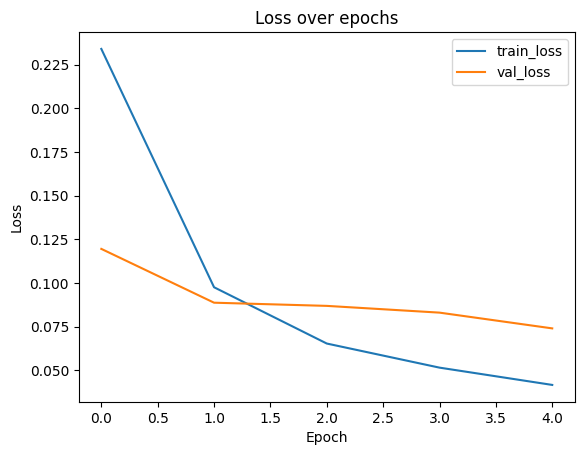

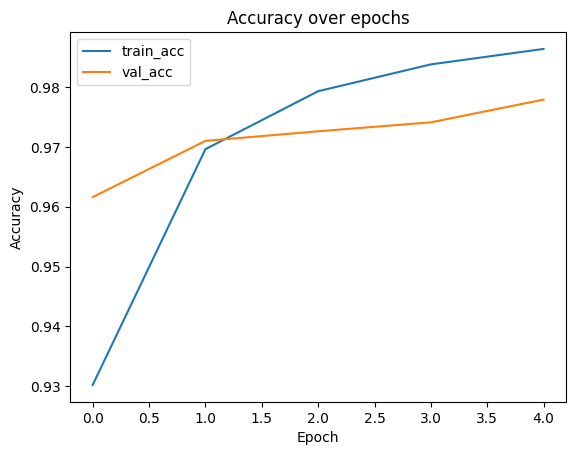

In [13]:
plt.figure()
plt.plot(history['train_loss'], label='train_loss')
plt.plot(history['val_loss'], label='val_loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.title('Loss over epochs')
plt.show()

plt.figure()
plt.plot(history['train_acc'], label='train_acc')
plt.plot(history['val_acc'], label='val_acc')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.title('Accuracy over epochs')
plt.show()

### Visualize predictions

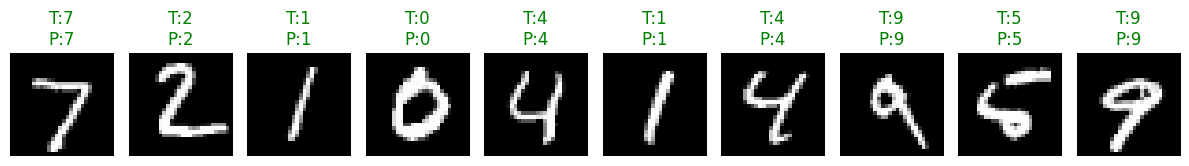

In [14]:
def show_predictions(model, dataset, n: int = 10):
    model.eval()
    plt.figure(figsize=(12, 3))
    for i in range(n):
        img, label = dataset[i]
        with torch.no_grad():
            logits = model(img.unsqueeze(0).to(device))
            pred_label = logits.argmax(dim=1).item()
        plt.subplot(1, n, i+1)
        plt.imshow(img.squeeze(0), cmap='gray')
        color = 'green' if pred_label == label else 'red'
        plt.title(f'T:{label}\nP:{pred_label}', color=color)
        plt.axis('off')
    plt.tight_layout()
    plt.show()

show_predictions(model, test_dataset, n=10)

### Improving performance
Here are PyTorch-friendly ways to improve accuracy:
1. **Use a CNN** (recommended for MNIST)
2. **Data augmentation** (random rotations/shifts)
3. **Learning rate scheduling**
4. **More epochs / AdamW / weight decay**

In [15]:
mlp_history = history  # keep MLP history
mlp_model = model      # keep MLP model

## CNN
### Example

In [16]:
class MNISTCNN(nn.Module):
    def __init__(self):
        super().__init__()
        self.features = nn.Sequential(
            nn.Conv2d(1, 32, 3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),  # 14x14
            nn.Conv2d(32, 64, 3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),  # 7x7
        )
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(64 * 7 * 7, 128),
            nn.ReLU(),
            nn.Linear(128, 10)
        )

    def forward(self, x):
        x = self.features(x)
        x = self.classifier(x)
        return x

In [17]:
# define CNN (we already had the class in the notebook)
cnn_model = MNISTCNN().to(device)

cnn_loss_fn = nn.CrossEntropyLoss()
cnn_optimizer = torch.optim.Adam(cnn_model.parameters(), lr=1e-3)

In [18]:
cnn_history = {"train_loss": [], "train_acc": [], "val_loss": [], "val_acc": []}

num_epochs_cnn = 5

for epoch in range(num_epochs_cnn):
    train_loss, train_acc = train_one_epoch(
        cnn_model, train_loader, cnn_loss_fn, cnn_optimizer, device
    )
    val_loss, val_acc = evaluate(
        cnn_model, test_loader, cnn_loss_fn, device
    )

    cnn_history["train_loss"].append(train_loss)
    cnn_history["train_acc"].append(train_acc)
    cnn_history["val_loss"].append(val_loss)
    cnn_history["val_acc"].append(val_acc)

    print(
        f"[CNN] Epoch {epoch+1}/{num_epochs_cnn} | "
        f"train_loss={train_loss:.4f}, train_acc={train_acc:.4f} | "
        f"val_loss={val_loss:.4f}, val_acc={val_acc:.4f}"
    )

[CNN] Epoch 1/5 | train_loss=0.1275, train_acc=0.9610 | val_loss=0.0360, val_acc=0.9883
[CNN] Epoch 2/5 | train_loss=0.0420, train_acc=0.9867 | val_loss=0.0395, val_acc=0.9858
[CNN] Epoch 3/5 | train_loss=0.0293, train_acc=0.9910 | val_loss=0.0326, val_acc=0.9889
[CNN] Epoch 4/5 | train_loss=0.0198, train_acc=0.9937 | val_loss=0.0392, val_acc=0.9869
[CNN] Epoch 5/5 | train_loss=0.0169, train_acc=0.9944 | val_loss=0.0386, val_acc=0.9880


### Show Predictions

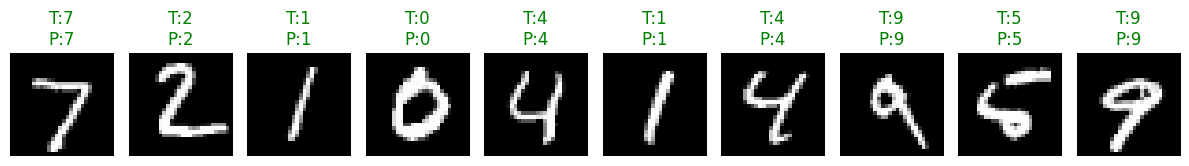

In [19]:
show_predictions(cnn_model, test_dataset, n=10)

## Plot Model Comparisons

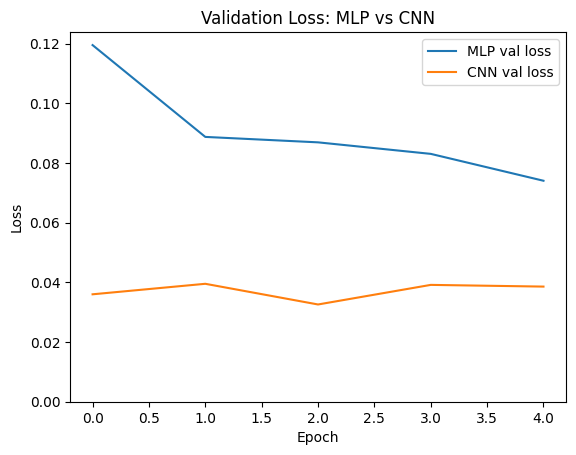

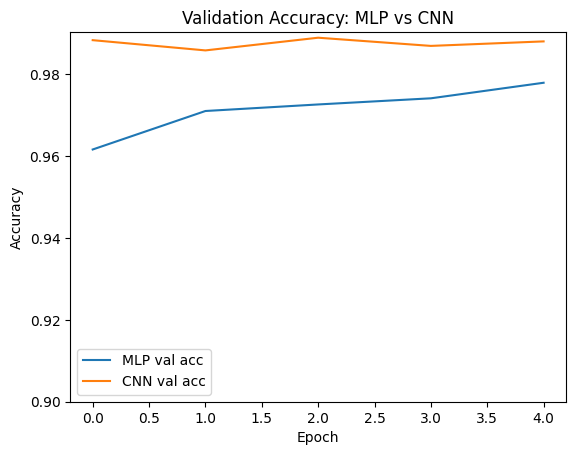

In [20]:
# compare loss
plt.figure()
plt.plot(mlp_history["val_loss"], label="MLP val loss")
plt.plot(cnn_history["val_loss"], label="CNN val loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Validation Loss: MLP vs CNN")
plt.legend()
plt.ylim(bottom=0)
plt.show()

# compare accuracy
plt.figure()
plt.plot(mlp_history["val_acc"], label="MLP val acc")
plt.plot(cnn_history["val_acc"], label="CNN val acc")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Validation Accuracy: MLP vs CNN")
plt.legend()
plt.ylim(bottom=0.9)
plt.show()

## CNN With optimal LR

In [21]:
cnn_model = MNISTCNN().to(device)
cnn_loss_fn = nn.CrossEntropyLoss()
# start with a reasonable LR
cnn_optimizer = torch.optim.Adam(cnn_model.parameters(), lr=1e-3)

cnn_comparison_history = {"train_loss": [], "train_acc": [], "val_loss": [], "val_acc": []}

num_epochs_cnn = 8
best_val_loss = float("inf")
best_state_dict = None
best_epoch = -1

In [22]:
for epoch in range(num_epochs_cnn):
    train_loss, train_acc = train_one_epoch(
        cnn_model, train_loader, cnn_loss_fn, cnn_optimizer, device
    )
    val_loss, val_acc = evaluate(
        cnn_model, test_loader, cnn_loss_fn, device
    )

    cnn_comparison_history["train_loss"].append(train_loss)
    cnn_comparison_history["train_acc"].append(train_acc)
    cnn_comparison_history["val_loss"].append(val_loss)
    cnn_comparison_history["val_acc"].append(val_acc)

    # 👇 save best
    if val_loss < best_val_loss:
        best_val_loss = val_loss
        best_state_dict = cnn_model.state_dict()
        best_epoch = epoch

    print(
        f"[CNN] Epoch {epoch+1}/{num_epochs_cnn} | "
        f"train_loss={train_loss:.4f}, train_acc={train_acc:.4f} | "
        f"val_loss={val_loss:.4f}, val_acc={val_acc:.4f}"
    )

print(f"Best val loss: {best_val_loss:.4f} at epoch {best_epoch+1}")


[CNN] Epoch 1/8 | train_loss=0.1328, train_acc=0.9598 | val_loss=0.0430, val_acc=0.9847
[CNN] Epoch 2/8 | train_loss=0.0414, train_acc=0.9869 | val_loss=0.0358, val_acc=0.9881
[CNN] Epoch 3/8 | train_loss=0.0277, train_acc=0.9912 | val_loss=0.0378, val_acc=0.9882
[CNN] Epoch 4/8 | train_loss=0.0200, train_acc=0.9932 | val_loss=0.0283, val_acc=0.9903
[CNN] Epoch 5/8 | train_loss=0.0152, train_acc=0.9953 | val_loss=0.0357, val_acc=0.9884
[CNN] Epoch 6/8 | train_loss=0.0109, train_acc=0.9966 | val_loss=0.0333, val_acc=0.9895
[CNN] Epoch 7/8 | train_loss=0.0110, train_acc=0.9963 | val_loss=0.0320, val_acc=0.9916
[CNN] Epoch 8/8 | train_loss=0.0080, train_acc=0.9972 | val_loss=0.0356, val_acc=0.9892
Best val loss: 0.0283 at epoch 4


### Train more epochs with best LR

In [23]:
extra_epochs = 3
for epoch in range(extra_epochs):
    train_loss, train_acc = train_one_epoch(
        cnn_model, train_loader, cnn_loss_fn, cnn_optimizer, device
    )
    val_loss, val_acc = evaluate(
        cnn_model, test_loader, cnn_loss_fn, device
    )
    print(
        f"[CONT] Epoch {epoch+1}/{extra_epochs} | "
        f"train_loss={train_loss:.4f}, train_acc={train_acc:.4f} | "
        f"val_loss={val_loss:.4f}, val_acc={val_acc:.4f}"
    )

[CONT] Epoch 1/3 | train_loss=0.0068, train_acc=0.9977 | val_loss=0.0338, val_acc=0.9920
[CONT] Epoch 2/3 | train_loss=0.0076, train_acc=0.9974 | val_loss=0.0345, val_acc=0.9913
[CONT] Epoch 3/3 | train_loss=0.0048, train_acc=0.9985 | val_loss=0.0409, val_acc=0.9916


In [24]:
# 
# "figure out" best LR
# 
def try_lrs(model_cls, lrs, train_loader, test_loader, device):
    results = []
    for lr in lrs:
        model = model_cls().to(device)
        loss_fn = nn.CrossEntropyLoss()
        optimizer = torch.optim.Adam(model.parameters(), lr=lr)

        train_loss, train_acc = train_one_epoch(model, train_loader, loss_fn, optimizer, device)
        val_loss, val_acc = evaluate(model, test_loader, loss_fn, device)

        results.append({
            "lr": lr,
            "train_loss": train_loss,
            "val_loss": val_loss,
            "val_acc": val_acc,
        })
        print(f"LR={lr:.5f} -> val_loss={val_loss:.4f}, val_acc={val_acc:.4f}")
    return results

lrs_to_test = [1e-4, 3e-4, 1e-3, 0.0015, 0.002, 0.0025, 3e-3, 0.004, 0.007,0.0095, 1e-2]

lr_results = try_lrs(MNISTCNN, lrs_to_test, train_loader, test_loader, device)

LR=0.00010 -> val_loss=0.1444, val_acc=0.9559
LR=0.00030 -> val_loss=0.0831, val_acc=0.9733
LR=0.00100 -> val_loss=0.0465, val_acc=0.9844
LR=0.00150 -> val_loss=0.0498, val_acc=0.9844
LR=0.00200 -> val_loss=0.0440, val_acc=0.9858
LR=0.00250 -> val_loss=0.0399, val_acc=0.9867
LR=0.00300 -> val_loss=0.0476, val_acc=0.9849
LR=0.00400 -> val_loss=0.0580, val_acc=0.9811
LR=0.00700 -> val_loss=0.0784, val_acc=0.9741
LR=0.00950 -> val_loss=0.1565, val_acc=0.9499
LR=0.01000 -> val_loss=0.1573, val_acc=0.9498


### Pick Best LR

In [25]:
best_lr_entry = min(lr_results, key=lambda x: x["val_loss"])
best_lr = best_lr_entry["lr"]
print("Best LR found:", best_lr)

Best LR found: 0.0025


### Visualize LR vs Loss

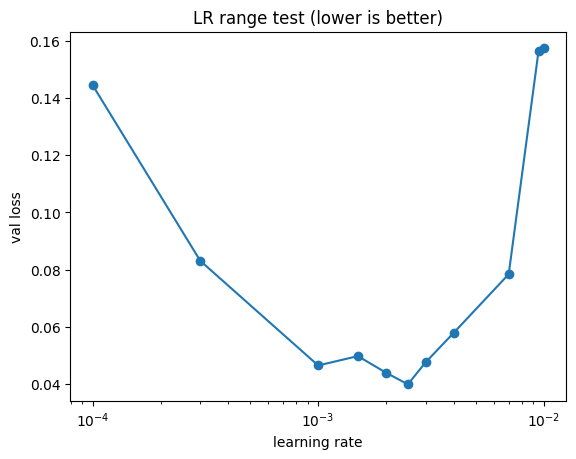

In [26]:
plt.figure()
plt.plot([r["lr"] for r in lr_results], [r["val_loss"] for r in lr_results], marker="o")
plt.xscale("log")
plt.xlabel("learning rate")
plt.ylabel("val loss")
plt.title("LR range test (lower is better)")
plt.show()

### Retrain With Optimal LR

In [27]:
best_lr_model = MNISTCNN().to(device)
loss_fn = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(best_lr_model.parameters(), lr=best_lr)

best_lr_history = {"train_loss": [], "train_acc": [], "val_loss": [], "val_acc": []}
epochs = 6

for epoch in range(epochs):
    train_loss, train_acc = train_one_epoch(best_lr_model, train_loader, loss_fn, optimizer, device)
    val_loss, val_acc = evaluate(best_lr_model, test_loader, loss_fn, device)

    best_lr_history["train_loss"].append(train_loss)
    best_lr_history["train_acc"].append(train_acc)
    best_lr_history["val_loss"].append(val_loss)
    best_lr_history["val_acc"].append(val_acc)

    print(
        f"[Best-LR CNN] Epoch {epoch+1}/{epochs} | "
        f"train_loss={train_loss:.4f}, train_acc={train_acc:.4f} | "
        f"val_loss={val_loss:.4f}, val_acc={val_acc:.4f}"
    )

[Best-LR CNN] Epoch 1/6 | train_loss=0.1353, train_acc=0.9576 | val_loss=0.0477, val_acc=0.9841
[Best-LR CNN] Epoch 2/6 | train_loss=0.0407, train_acc=0.9872 | val_loss=0.0453, val_acc=0.9867
[Best-LR CNN] Epoch 3/6 | train_loss=0.0296, train_acc=0.9904 | val_loss=0.0377, val_acc=0.9871
[Best-LR CNN] Epoch 4/6 | train_loss=0.0228, train_acc=0.9928 | val_loss=0.0333, val_acc=0.9888
[Best-LR CNN] Epoch 5/6 | train_loss=0.0182, train_acc=0.9940 | val_loss=0.0385, val_acc=0.9882
[Best-LR CNN] Epoch 6/6 | train_loss=0.0159, train_acc=0.9948 | val_loss=0.0397, val_acc=0.9885


## CNN-Comparison Viz

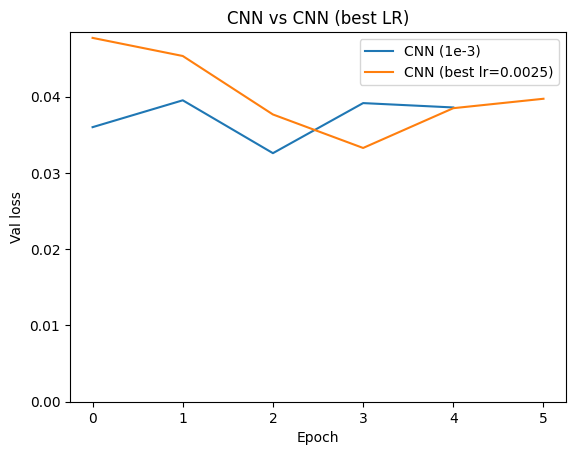

In [28]:
plt.figure()
plt.plot(cnn_history["val_loss"], label="CNN (1e-3)")
plt.plot(best_lr_history["val_loss"], label=f"CNN (best lr={best_lr})")
plt.xlabel("Epoch")
plt.ylabel("Val loss")
plt.ylim(bottom=0)
plt.legend()
plt.title("CNN vs CNN (best LR)")
plt.show()


## 🧩 Optimizer Tuning & Learning Rate Insights

By experimenting with the **learning rate** and **number of epochs**, we can see how sensitive deep learning models are to optimization settings.

- The *learning rate* determines **how big each step** in the gradient descent process is.  
  - Too high → unstable training or oscillating loss.  
  - Too low → very slow convergence.  
  - Just right → smooth and steady improvement.

- The *best loss value* represents the model parameters that minimize the validation loss.  
  - Saving and restoring these weights (`best_state_dict`) helps us retain the model at its optimal state before overfitting begins.

- Running **additional epochs** after reaching the best loss can reveal whether the model is still improving or starting to overfit.

- A quick **learning-rate range test** helps identify where loss improves fastest.  
  - Training again with that “best” LR often yields faster convergence and better accuracy.

🧠 *Takeaway:*  
Optimizing a neural network isn’t just about architecture — **the optimizer settings (learning rate, epochs, batch size)** can make or break model performance.  
Even small tuning changes can turn a 97% model into a 99% model!
